# Olympic Medal Analysis

## Objective

- Analyze historical Olympic Games data from 1896 to 2016.
- Explore trends in athlete participation across different Olympic years.
- Identify the countries with the highest number of Olympic medals.
- Examine medal distribution across different sports and nations.
- Analyze changes in male and female participation over time.
- Investigate athlete characteristics, including age, height, and weight patterns.
- Use data visualization techniques to communicate important trends and findings.
- Apply data cleaning and exploratory data analysis methods to extract meaningful insights from the dataset.

## Import Libraries 

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

plt.style.use('seaborn-v0_8-darkgrid')

plt.rcParams.update({
    'font.size': 13,
    'axes.labelsize': 14,
    'axes.titlesize': 18,
    'axes.titleweight': "bold",
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.loc': 'best',
    'legend.frameon': True,
    'lines.linewidth': 2.5,
    'patch.edgecolor': 'black',
    'patch.force_edgecolor': True, 
    'savefig.dpi': 300
})    

def save_figure(filename):
    plt.tight_layout()
    plt.savefig(
        Path('../images') / filename, 
        bbox_inches='tight'
    )

## Lead Dataset

In [57]:
raw_df = pd.read_csv('../data/athlete_events.csv')

df = raw_df.copy()

## Initial Data Inspection 

In [58]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [59]:
rows, columns = df.shape

print(f'rows: {rows}, columns: {columns}')

rows: 271116, columns: 15


In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  str    
 2   Sex     271116 non-null  str    
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  str    
 7   NOC     271116 non-null  str    
 8   Games   271116 non-null  str    
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  str    
 11  City    271116 non-null  str    
 12  Sport   271116 non-null  str    
 13  Event   271116 non-null  str    
 14  Medal   39783 non-null   str    
dtypes: float64(3), int64(2), str(10)
memory usage: 31.0 MB


In [61]:
df.describe()

,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


In [62]:
df['NOC'].nunique()

230

In [63]:
df['Sport'].nunique()

66

In [64]:
df['Sex'].value_counts()

Sex
M    196594
F     74522
Name: count, dtype: int64

In [65]:
df['Season'].value_counts()

Season
Summer    222552
Winter     48564
Name: count, dtype: int64

In [66]:
df['Medal'].value_counts(dropna=False)

Medal
NaN       231333
Gold       13372
Bronze     13295
Silver     13116
Name: count, dtype: int64

### Observations 

- The dataset contains 15 variables, including both categorical and numerical features, describing Olympic participants from 230 National Olympic Committees (NOCs) who competed in 66 sports between 1896 and 2016.       
- The majority of athletes in the dataset are male, indicating that male participation has historically exceeded female participation across the Olympic Games.        
         
- The dataset contains substantially more records for the Summer Olympics than for the Winter Olympics. This is expected because the Summer Games include more sports, events, and participating athletes. 

## Data Quality Assessment 

In [67]:
df.isnull().sum()

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
dtype: int64

In [68]:
df.loc[df['Age'].argmin()]

ID                                        71691
Name                         Dimitrios Loundras
Sex                                           M
Age                                        10.0
Height                                      NaN
Weight                                      NaN
Team              Ethnikos Gymnastikos Syllogos
NOC                                         GRE
Games                               1896 Summer
Year                                       1896
Season                                   Summer
City                                     Athina
Sport                                Gymnastics
Event     Gymnastics Men's Parallel Bars, Teams
Medal                                    Bronze
Name: 142882, dtype: object

In [69]:
df.loc[df['Age'].argmax()]

ID                                             128719
Name                           John Quincy Adams Ward
Sex                                                 M
Age                                              97.0
Height                                            NaN
Weight                                            NaN
Team                                    United States
NOC                                               USA
Games                                     1928 Summer
Year                                             1928
Season                                         Summer
City                                        Amsterdam
Sport                                Art Competitions
Event     Art Competitions Mixed Sculpturing, Statues
Medal                                             NaN
Name: 257054, dtype: object

In [70]:
df.loc[df['Height'].argmin()]

ID                                           15150
Name                               Rosario Briones
Sex                                              F
Age                                           15.0
Height                                       127.0
Weight                                        42.0
Team                                        Mexico
NOC                                            MEX
Games                                  1968 Summer
Year                                          1968
Season                                      Summer
City                                   Mexico City
Sport                                   Gymnastics
Event     Gymnastics Women's Individual All-Around
Medal                                          NaN
Name: 29333, dtype: object

In [71]:
df.loc[df['Height'].argmax()]

ID                             132627
Name                         Yao Ming
Sex                                 M
Age                              20.0
Height                          226.0
Weight                          141.0
Team                            China
NOC                               CHN
Games                     2000 Summer
Year                             2000
Season                         Summer
City                           Sydney
Sport                      Basketball
Event     Basketball Men's Basketball
Medal                             NaN
Name: 265040, dtype: object

In [72]:
df.loc[df['Weight'].argmin()]

ID                                           21049
Name                                Choi Myong-Hui
Sex                                              F
Age                                           14.0
Height                                       135.0
Weight                                        25.0
Team                                   North Korea
NOC                                            PRK
Games                                  1980 Summer
Year                                          1980
Season                                      Summer
City                                        Moskva
Sport                                   Gymnastics
Event     Gymnastics Women's Individual All-Around
Medal                                          NaN
Name: 40849, dtype: object

In [73]:
df.loc[df['Weight'].argmax()]

ID                         12177
Name           Ricardo Blas, Jr.
Sex                            M
Age                         21.0
Height                     183.0
Weight                     214.0
Team                        Guam
NOC                          GUM
Games                2008 Summer
Year                        2008
Season                    Summer
City                     Beijing
Sport                       Judo
Event     Judo Men's Heavyweight
Medal                        NaN
Name: 23155, dtype: object

In [74]:
df.duplicated().sum()

np.int64(1385)

In [75]:
df[df.duplicated()].head(20)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
1252,704,Dsir Antoine Acket,M,27.0,NaN,NaN,Belgium,BEL,1932 Summer,1932,Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",NaN
4282,2449,William Truman Aldrich,M,48.0,NaN,NaN,United States,USA,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Painting, Drawings And ...",NaN
4283,2449,William Truman Aldrich,M,48.0,NaN,NaN,United States,USA,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Painting, Drawings And ...",NaN
4862,2777,Hermann Reinhard Alker,M,43.0,NaN,NaN,Germany,GER,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Designs F...",NaN
4864,2777,Hermann Reinhard Alker,M,43.0,NaN,NaN,Germany,GER,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Architect...",NaN
4867,2777,Hermann Reinhard Alker,M,51.0,NaN,NaN,Germany,GER,1936 Summer,1936,Summer,Berlin,Art Competitions,"Art Competitions Mixed Architecture, Unknown E...",NaN
5105,2903,Lucien Charles Edouard Alliot,M,46.0,NaN,NaN,France,FRA,1924 Summer,1924,Summer,Paris,Art Competitions,Art Competitions Mixed Sculpturing,NaN
5106,2903,Lucien Charles Edouard Alliot,M,46.0,NaN,NaN,France,FRA,1924 Summer,1924,Summer,Paris,Art Competitions,Art Competitions Mixed Sculpturing,NaN
7770,4319,Ludwig Angerer,M,41.0,NaN,NaN,Germany,GER,1932 Summer,1932,Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",NaN
7771,4319,Ludwig Angerer,M,41.0,NaN,NaN,Germany,GER,1932 Summer,1932,Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",NaN


### Findings 

- Several numerical variables contain missing values, particularly Age, Height, and Weight. The Medal column also contains many missing values; however, this is expected, as most athletes did not win medal.       
- Several extreme values were identified in the Age, Height, and Weight columns. After inspection, these values appear plausible given the athletes' age, sex, and sport, and are therefore not considered data errors.      
- The categorical variables Sex, Season, and Medal contain consistent values with no obvious spelling inconsistencies or duplicate categories.    
- The dataset contains a number of duplicate records. Inspection indicates these rows are identical across all variables and therefore represent redundant observations. They will be removed during the data-cleaning stage to prevent duplicate counting in subsequent analyses.

## Data Cleaning

In [76]:
df = df.drop_duplicates()

### Data Cleaning Summary

- Duplicate records were removed to prevent repeated counting of athletes and medals.
- Missing values in Age, Height, and Weight were retained because these variables are not required for all analyses.
- Missing Medal values were preserved because they represent athletes who participated but did not receive medals.

# Exploratory Data Analysis (EDA)

## Olympic Participation Trends

In [77]:
athletes_by_season = df.groupby(['Season', 'Year'])['ID'].nunique()

summer_athletes = athletes_by_season.loc['Summer']
winter_athletes = athletes_by_season.loc['Winter']

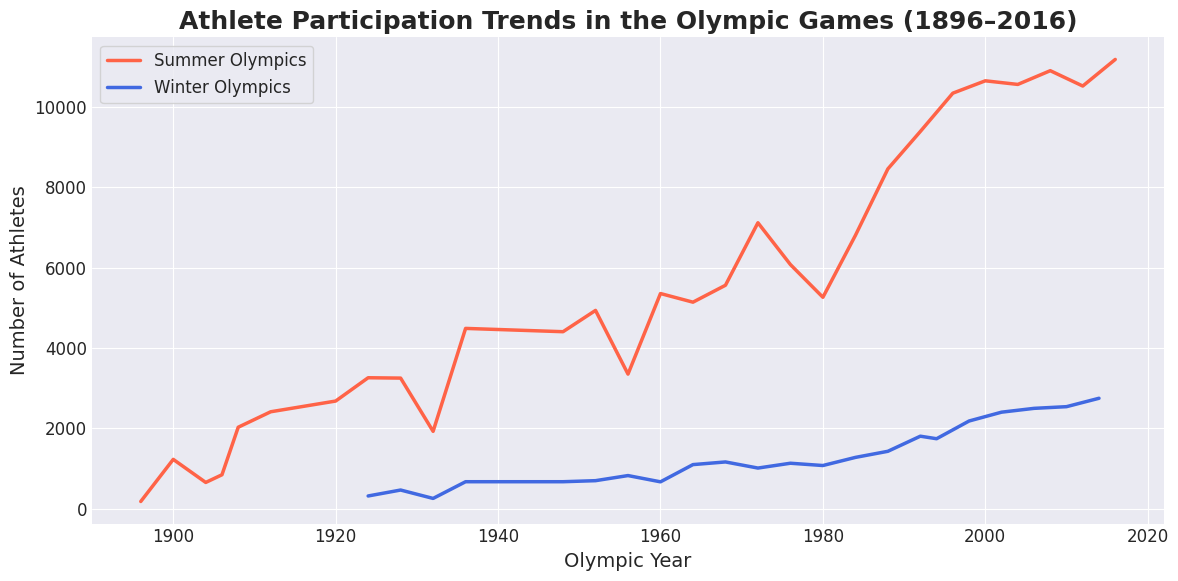

In [78]:
plt.figure(figsize=(12,6))

plt.plot(summer_athletes, color='tomato', label='Summer Olympics')
plt.plot(winter_athletes, color='royalblue', label='Winter Olympics')

plt.xlabel('Olympic Year')
plt.ylabel('Number of Athletes')
plt.title('Athlete Participation Trends in the Olympic Games (1896–2016)')

plt.legend()

save_figure('olympic_participation_trends_athletes.png')
plt.show()

In [79]:
countries_by_season = df.groupby(['Season', 'Year'])['NOC'].nunique()

summer_countries = countries_by_season.loc['Summer']
winter_countries = countries_by_season.loc['Winter']

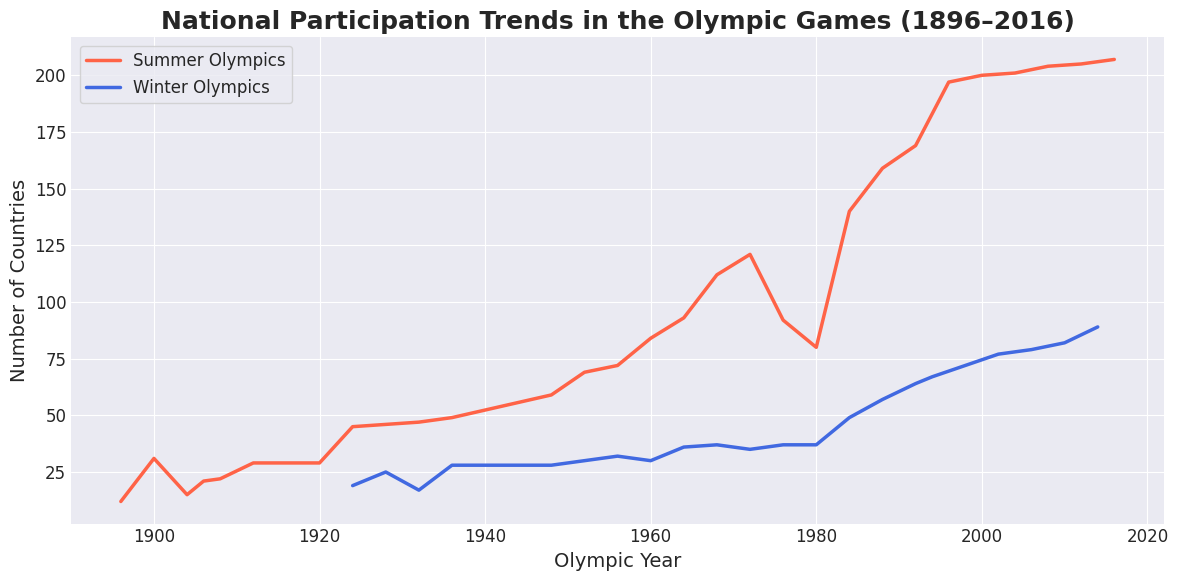

In [80]:
plt.figure(figsize=(12,6))

plt.plot(summer_countries, color='tomato', label='Summer Olympics')
plt.plot(winter_countries, color='royalblue', label='Winter Olympics')

plt.xlabel('Olympic Year')
plt.ylabel('Number of Countries')
plt.title('National Participation Trends in the Olympic Games (1896–2016)')

plt.legend()

save_figure('olympic_participation_trends_countries.png')
plt.show()

### Interpretation 

The graphs show a clear long-term growth trend in Olympic participation for both athletes and participating countries. Summer Olympic participation has increased substantially over time, with some fluctuations during certain periods caused by historical events, including interruptions and changes in Olympic organisation. The number of participating countries also shows a strong upward trend, reflecting the global expansion and increasing accessibility of the Olympic Games.

Winter Olympic participation follows a similar pattern, although at a smaller scale compared with the Summer Games. The growth in both athletes and countries indicates increasing international involvement and development of winter sports worldwide. Overall, the trends suggest that the Olympic Games have evolved from a relatively limited international competition into a large-scale global sporting event with broader representation across nations and disciplines.

## Country Performance Analysis

In [81]:
country_medals = df.groupby('NOC')['Medal'].count()

top_countries = country_medals.sort_values(ascending=False).head(10)

top_countries

NOC
USA    5637
URS    2503
GER    2165
GBR    2067
FRA    1767
ITA    1637
SWE    1536
CAN    1352
AUS    1320
RUS    1165
Name: Medal, dtype: int64

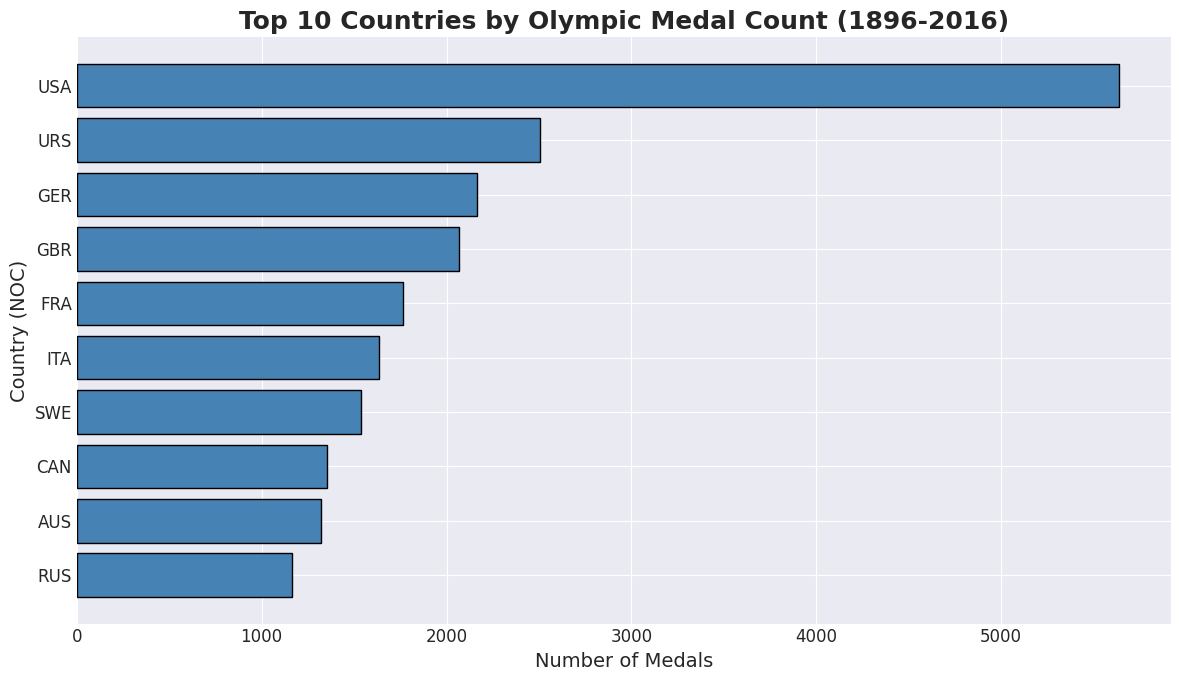

In [82]:
plt.figure(figsize=(12,7))

plt.barh(
    top_countries.index,
    top_countries.values, 
    color='steelblue'
)

plt.xlabel('Number of Medals')
plt.ylabel('Country (NOC)')
plt.title('Top 10 Countries by Olympic Medal Count (1896-2016)')

plt.gca().invert_yaxis()

save_figure('country_performance_analysis.png')
plt.show()

### Interpretation 

The analysis shows a clear difference in Olympic medal performance between countries. A small group of nations has historically achieved significantly higher medal totals compared with other countries, indicating long-term dominance in Olympic competition.

The leading countries have maintained strong performances due to factors such as consistent athlete development programs, greater investment in sports infrastructure, and participation across a wide range of Olympic events.

The distribution also shows that medal success is not evenly spread among all nations. Countries with large sporting traditions and longer Olympic histories tend to appear among the highest-performing nations, while many countries have comparatively fewer medals.

## Sport Medal Analysis

In [83]:
sport_medals = df.groupby('Sport')['Medal'].count()
top_sports = sport_medals.sort_values(ascending=False).head(10)

top_sports

Sport
Athletics     3969
Swimming      3048
Rowing        2945
Gymnastics    2256
Fencing       1743
Football      1571
Ice Hockey    1530
Hockey        1528
Wrestling     1296
Cycling       1263
Name: Medal, dtype: int64

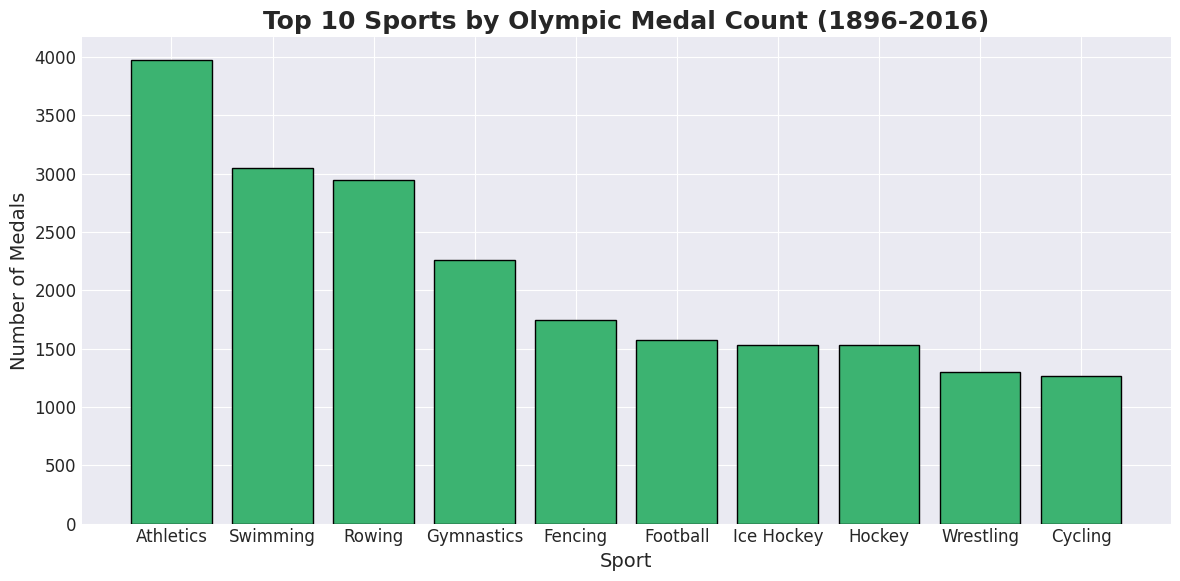

In [84]:
plt.figure(figsize=(12,6))

plt.bar(
    top_sports.index, 
    top_sports.values, 
    color='mediumseagreen'
)

plt.xlabel('Sport')
plt.ylabel('Number of Medals')
plt.title('Top 10 Sports by Olympic Medal Count (1896-2016)') 

save_figure('sport_medal_analysis.png')
plt.show()

### Interpretation 

The analysis shows that medal distribution is not evenly spread across sports. A small number of sports account for a large proportion of Olympic medals, likely due to the number of events and disciplines available within those sports. Sports with multiple competitions and long Olympic histories tend to appear among the highest medal-producing categories.

The results also highlight differences in the popularity, structure, and competitive opportunities of various sports. Sports with fewer events or shorter Olympic histories generally contribute fewer medals. However, a lower medal count does not necessarily indicate lower importance or competitiveness, as some sports have fewer opportunities for athletes to win medals.

Overall, the distribution suggests that Olympic medal outcomes are strongly influenced by the number of events available within each sport, rather than only by the number of participating athletes or countries.

## Gender Participation Trends

In [85]:
athletes_by_gender = (
    df
    .groupby(['Year', 'Sex'])['ID']
    .nunique()
    .unstack(fill_value=0)
    .astype(int)
)

athletes_by_gender['total'] = athletes_by_gender.sum(axis=1)

athletes_by_gender['F%'] = athletes_by_gender['F'] / athletes_by_gender['total'] * 100

athletes_by_gender['M%'] = athletes_by_gender['M'] / athletes_by_gender['total'] * 100

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(athletes_by_gender['F%'], color='crimson', label='Female')
plt.plot(athletes_by_gender['M%'], color='steelblue', label='Male')

plt.xlabel('Olympic Year')
plt.ylabel('Athletes (%)')
plt.title('Gender Participation Trends in the Olympic Games (1896–2016)')

plt.ylim(0,100)
plt.legend(title='Gender')

save_figure('gender_participation_trends.png')
plt.show()

### Interpretation 

The graph shows a clear long-term shift in Olympic participation by gender. Female participation has steadily increased throughout Olympic history, while male participation has gradually declined as a proportion of total athletes. 

The early Olympic Games were heavily dominated by male athletes, reflecting the limited opportunities available for women in competitive sports at that time. Over the decades, female representation increased as more events were opened to women and participation opportunities expanded.

Although the trend is not perfectly linear, with some fluctuations between Olympic Games, the overall pattern indicates a continuous movement toward greater gender balance in Olympic participation. By the modern era, the difference between male and female participation had become much smaller compared with the early years of the Games.

## Country Dominance by Sport

In [ ]:
sport_dominance = df.groupby(['Sport', 'NOC'])['Medal'].count()

def get_top_countries(sport):
    return (
        sport_dominance
        .loc[sport]
        .sort_values(ascending=False)
        .head(10)
    )

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(get_top_countries('Athletics').index, 
         get_top_countries('Athletics').values,
         color='firebrick'
        )

plt.xlabel('Number of Medals')
plt.ylabel('Country (NOC)')
plt.title('Top 10 Countries by Olympic Medals in Athletics (1896-2016)')

save_figure('country_dominance_by_sport_athletics.png')
plt.show()

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(
    get_top_countries('Swimming').index,
    get_top_countries('Swimming').values,
    color='deepskyblue'
)

plt.xlabel('Number of Medals')
plt.ylabel('Countries (NOC)')
plt.title('Top 10 Countries by Olympic Medals in Swimming (1896-2016)')

save_figure('country_dominance_by_sport_swimming.png') 
plt.show()

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(
    get_top_countries('Rowing').index,
    get_top_countries('Rowing').values,
    color='darkorange'
)

plt.xlabel('Number of Medals')
plt.ylabel('Countries (NOC)')
plt.title('Top 10 Countries by Olympic Medals in Rowing (1896-2016)')

save_figure('country_dominance_by_sport_rowing.png') 
plt.show()

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(
    get_top_countries('Gymnastics').index,
    get_top_countries ('Gymnastics').values,
    color='mediumpurple'
)

plt.xlabel('Number of Medals')
plt.ylabel('Countries (NOC)')
plt.title('Top 10 Countries by Olympic Medals in Gymnastics (1896-2016)')

save_figure('country_dominance_by_sport_gymnastics.png') 
plt.show()

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(
    get_top_countries('Fencing').index,
    get_top_countries('Fencing').values,
    color='slategray'
)

plt.xlabel('Number of Medals')
plt.ylabel('Countries (NOC)')
plt.title('Top 10 Countries by Olympic Medals in Fencing (1896-2016)')

save_figure('country_dominance_by_sport_fencing.png') 
plt.show()

### Interpretation 

The analysis shows that Olympic dominance varies considerably between sports, with different countries establishing long-term strengths in specific disciplines. Some sports display clear historical dominance by a small number of nations, while others show more balanced competition among multiple countries.

In swimming, the results indicate a strong and consistent performance from a few leading nations, suggesting that factors such as investment in training systems, competitive infrastructure, and sporting traditions have played an important role. Similar patterns can be observed in rowing, where several countries have maintained strong performances over many Olympic cycles.

Gymnastics shows a different pattern, with dominance shifting between countries across different periods. Historical sporting programs and changes in national training systems appear to have influenced which countries achieved the highest success. This suggests that Olympic success is not only determined by population size or resources but also by specialized development programs within individual sports.

Overall, the results demonstrate that Olympic success is highly sport-specific. Countries that dominate one discipline may not necessarily perform at the same level in others, highlighting the importance of national expertise, historical development, and specialization in competitive sports.

## Athlete Age Trends

In [ ]:
average_age_by_year = df.groupby(['Year'])['Age'].mean()

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(average_age_by_year, color='navy')

plt.xlabel('Olympic Year')
plt.ylabel('Average Athlete Age (Years)')
plt.title('Average Athlete Age by Olympic Year (1896–2016)')

save_figure('athlete_age_trends_by_year.png')
plt.show()

In [ ]:
average_age_by_sport = df.groupby('Sport')['Age'].mean()

youngest_by_sport = average_age_by_sport.sort_values().head(10)
oldest_by_sport = average_age_by_sport.sort_values(ascending=False).head(10)

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(
    youngest_by_sport.index,
    youngest_by_sport.values,
    color='teal'
)

plt.xlabel('Sport')
plt.ylabel('Average Athlete Age (Years)')
plt.title('Top 10 Sports with Youngest Athletes (1896-2016)')

plt.xticks(rotation=45, ha='right')

save_figure('athlete_age_trends_by_sport_youngest.png')
plt.show()

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(
    oldest_by_sport.index,
    oldest_by_sport.values,
    color='coral'
)

plt.xlabel('Sport')
plt.ylabel('Avergae Athlete Age (Years)')
plt.title('Top 10 Sports with Oldest Athletes (1896-2016)')

plt.xticks(rotation=45, ha='right')

save_figure('athlete_age_trends_by_sport_oldest.png')
plt.show()

### Interpretation 

The analysis shows that athlete age has changed throughout Olympic history, with average participant age decreasing during much of the 20th century before gradually increasing again in more recent Olympic Games. This suggests changes in athlete development, training systems, and the evolution of different sports over time.

Age patterns also vary considerably between sports. Sports that emphasize flexibility, speed, and early specialization tend to have younger athletes, while sports that require greater experience, strength, or technical maturity generally include older participants. The differences between the youngest and oldest sports highlight how the physical and competitive demands of each sport influence the typical age profile of its athletes.

Overall, athlete age is not constant across Olympic history or across sports. Instead, it reflects changes in sporting culture, training methods, and the unique requirements of each discipline.

## Conclusion

This project analysed historical Olympic Games data from 1896 to 2016 to investigate changes in athlete participation, medal performance, sport distribution, gender representation, and athlete characteristics. Through data cleaning and exploratory data analysis, several important patterns were identified in the development of the Olympic Games over time.

The analysis showed that Olympic participation has expanded significantly, with increasing numbers of athletes and countries participating across both Summer and Winter Games. Medal success was found to be concentrated among a relatively small group of countries, reflecting differences in sporting traditions, investment, infrastructure, and historical participation. The distribution of medals across sports demonstrated that opportunities for medal success are strongly influenced by the number of events available within each discipline.

The study also highlighted major changes in gender representation, with female participation increasing substantially throughout Olympic history and moving towards greater balance between male and female athletes. Additionally, athlete age patterns varied across different sports, demonstrating the influence of sport-specific requirements, training systems, and competitive structures.

Overall, the analysis demonstrates how exploratory data analysis can be used to uncover meaningful historical trends within a large sports dataset. The Olympic Games have evolved from a smaller international competition into a highly diverse global event, with changes in participation, performance, and athlete demographics reflecting broader developments in sports and society.

## Limitations 

Although this analysis provides useful insights into Olympic trends, several limitations should be considered. The dataset contains information about athletes and medal outcomes but does not include many external factors that may influence Olympic success, such as national population size, economic conditions, sports funding, training facilities, coaching systems, or political factors.

Some variables, including Age, Height, and Weight, contain missing values. These missing values were retained because removing them would reduce the size of the dataset and could introduce unnecessary bias. However, incomplete information may affect some athlete characteristic analyses.

The dataset also represents Olympic participation records rather than complete athlete histories. Some athletes may appear multiple times because they competed in multiple events or Olympic Games, meaning that individual athlete counts and participation counts are not always equivalent. Additionally, medal totals alone do not fully represent sporting performance because countries have different numbers of opportunities depending on the sports and events in which they participate.

Finally, historical comparisons should be interpreted carefully because the Olympic Games have changed significantly over time, including the addition of new sports, changes in event structures, and differences in global participation.

## Future Work

Future improvements could extend this analysis by incorporating additional datasets and applying more advanced analytical methods. For example, combining Olympic data with information such as population size, GDP, sports investment, or national development indicators could provide deeper insights into the factors influencing Olympic success.

Further analysis could also investigate athlete career patterns, including the number of Olympic appearances, medal progression over time, and differences between individual and team sports. More advanced statistical methods could be applied to identify relationships between athlete characteristics, sport participation, and medal outcomes.

Another possible extension would be the development of an interactive dashboard using tools such as Streamlit or Plotly Dash, allowing users to explore Olympic trends dynamically by country, sport, year, and athlete characteristics. Machine learning approaches could also be explored in future work to predict medal outcomes or identify factors associated with higher Olympic performance.